# HiFormer — Reimplementazione su Synapse
### Esame di Deep Learning — Università di Firenze

Reimplementazione di **HiFormer-S** per la segmentazione multi-organo sul dataset Synapse.  
L'architettura combina un encoder CNN (ResNet34) e uno Swin Transformer, connessi  
tramite il modulo **DLF (Double-Level Fusion)** basato su cross-attention.

**Riferimento:** Heidari et al., *HiFormer: Hierarchical Multi-scale Representations  
Using Transformers for Medical Image Segmentation*, WACV 2023.

---
### Fix rispetto alla versione precedente
- **HD95 con voxelspacing corretto** (distanze in mm, non pixel)
- **Post-processing: largest connected component** per eliminare blob spurii
- **Decoder con skip al livello più fine** (fix perdita info spaziale)
- **Checkpoint con timestamp** — nessuna sovrascrittura tra run
- **Salvataggio ogni 5 epoche** — protezione da crash Colab
- **Migliore gestione edge case** nelle metriche (classi assenti)


## 1. Setup ambiente

In [34]:
!nvidia-smi

Mon Mar 16 16:28:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             55W /  400W |    3014MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [35]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive montato!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montato!


In [36]:
import os
path = '/content/drive/MyDrive/HiFormer/'
print(os.listdir(path))

['data.zip', 'data', 'checkpoints', 'weights', 'code', 'results']


In [37]:
print(os.listdir('/content/drive/MyDrive/HiFormer/data/Synapse'))

['test_vol_h5', 'train_npz']


In [38]:
train_files = os.listdir('/content/drive/MyDrive/HiFormer/data/Synapse/train_npz')
test_files  = os.listdir('/content/drive/MyDrive/HiFormer/data/Synapse/test_vol_h5')
print(f"File di training: {len(train_files)}")
print(f"File di test:     {len(test_files)}")
print(f"Esempio train: {train_files[:3]}")
print(f"Esempio test:  {test_files[:3]}")

File di training: 2211
File di test:     12
Esempio train: ['case0033_slice033.npz', 'case0033_slice032.npz', 'case0033_slice034.npz']
Esempio test:  ['case0025.npy.h5', 'case0022.npy.h5', 'case0035.npy.h5']


In [39]:
!pip install -q ml_collections medpy SimpleITK tensorboardX einops timm
print("Dipendenze installate")

Dipendenze installate


In [40]:
import torch
import torch.nn as nn
import numpy as np
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponibile: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA disponibile: True
GPU: NVIDIA A100-SXM4-40GB


## 2. Struttura del progetto

In [41]:
import os

LOCAL = '/content/hiformer_project'
DRIVE = '/content/drive/MyDrive/HiFormer/code'

for base in [LOCAL, DRIVE]:
    for d in ['configs', 'models', 'datasets', 'lists/lists_Synapse']:
        os.makedirs(f'{base}/{d}', exist_ok=True)

print("Cartelle create")

Cartelle create


## 3. Pesi Swin Transformer pretrained

In [42]:
weights_path = '/content/drive/MyDrive/HiFormer/weights/swin_tiny_patch4_window7_224.pth'

if not os.path.exists(weights_path):
    os.makedirs(os.path.dirname(weights_path), exist_ok=True)
    !wget -q https://github.com/SwinTransformer/storage/releases/download/v1.0.0/swin_tiny_patch4_window7_224.pth \
        -O {weights_path}
    print("Pesi scaricati")
else:
    print("Pesi già presenti")

Pesi già presenti


## 4. Configurazione del modello (HiFormer-S)

HiFormer-S usa **Swin Tiny** come branch transformer e **ResNet34** come branch CNN.

In [43]:
content = """
import ml_collections

def get_hiformer_s_config():
    config = ml_collections.ConfigDict()
    config.model_name      = 'hiformer-s'
    config.img_size        = 224
    config.num_classes     = 9
    config.in_chans        = 1

    # Swin Tiny
    config.swin_pretrained_path = '/content/drive/MyDrive/HiFormer/weights/swin_tiny_patch4_window7_224.pth'
    config.embed_dim       = 96
    config.depths          = [2, 2, 6, 2]
    config.num_heads       = [3, 6, 12, 24]
    config.window_size     = 7
    config.mlp_ratio       = 4.0
    config.qkv_bias        = True
    config.drop_rate       = 0.0
    config.attn_drop_rate  = 0.0
    config.drop_path_rate  = 0.1

    # ResNet34 (CNN encoder)
    config.cnn_backbone    = 'resnet34'
    config.cnn_pretrained  = True
    config.cnn_embed_dims  = [64, 128, 256, 512]

    # Decoder — ora usa skip a tutti e 4 i livelli
    config.skip_dims         = [512, 256, 128, 64]
    config.decoder_channels  = [256, 128, 64, 16]

    config.patch_size = 4
    return config
"""

for base in [LOCAL, DRIVE]:
    with open(f'{base}/configs/HiFormer_configs.py', 'w') as f:
        f.write(content)
    open(f'{base}/configs/__init__.py', 'w').close()

print("configs/HiFormer_configs.py salvato")


configs/HiFormer_configs.py salvato


## 5. Loss e metriche

**Fix rispetto alla versione precedente:**
- `calculate_metric_percase` ora accetta `voxelspacing` → HD95 in mm
- Gestione corretta delle classi assenti (classe assente in entrambi → Dice=1, HD95=0)
- `keep_largest_connected_component` per eliminare blob spurii prima della valutazione
- `test_single_volume` passa lo spacing corretto dal volume h5


In [44]:
content = """
import numpy as np
import torch
import torch.nn as nn
from medpy import metric
from scipy.ndimage import zoom
from scipy.ndimage import label as scipy_label
import SimpleITK as sitk


# ── Loss ────────────────────────────────────────────────────────────────────

class DiceLoss(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.n_classes = n_classes

    def _one_hot_encoder(self, input_tensor):
        tensor_list = []
        for i in range(self.n_classes):
            temp_prob = input_tensor == i
            tensor_list.append(temp_prob.unsqueeze(1))
        return torch.cat(tensor_list, dim=1).float()

    def _dice_loss(self, score, target):
        target = target.float()
        smooth = 1e-5
        intersect = torch.sum(score * target)
        y_sum = torch.sum(target * target)
        z_sum = torch.sum(score * score)
        return 1 - (2 * intersect + smooth) / (z_sum + y_sum + smooth)

    def forward(self, inputs, target, weight=None, softmax=False):
        if softmax:
            inputs = torch.softmax(inputs, dim=1)
        target = self._one_hot_encoder(target)
        if weight is None:
            weight = [1] * self.n_classes
        assert inputs.size() == target.size()
        loss = 0.0
        for i in range(self.n_classes):
            loss += self._dice_loss(inputs[:, i], target[:, i]) * weight[i]
        return loss / self.n_classes


# ── Post-processing ─────────────────────────────────────────────────────────

def keep_largest_connected_component(pred_volume, num_classes):
    \"\"\"
    Per ogni classe, mantieni solo la componente connessa più grande.
    Elimina blob spurii isolati che fanno esplodere HD95.
    \"\"\"
    result = np.zeros_like(pred_volume)
    for c in range(1, num_classes):
        binary = (pred_volume == c).astype(np.uint8)
        if binary.sum() == 0:
            continue
        labeled, n_components = scipy_label(binary)
        if n_components == 1:
            result[binary == 1] = c
            continue
        sizes = [(labeled == i).sum() for i in range(1, n_components + 1)]
        largest = np.argmax(sizes) + 1
        result[labeled == largest] = c
    return result


# ── Metriche ────────────────────────────────────────────────────────────────

def calculate_metric_percase(pred, gt, voxelspacing=None):
    \"\"\"
    Calcola Dice e HD95 per una coppia (predizione, ground truth) binaria.

    voxelspacing: tupla (sz, sy, sx) in mm — se None, usa pixel.
    Gestione edge case:
      - entrambi vuoti  → Dice=1, HD95=0 (perfetto per assenza)
      - solo pred vuota → Dice=0, HD95=0 (organo mancato, HD indefinito)
      - solo gt vuota   → Dice=0, HD95=0 (falso positivo)
    \"\"\"
    pred = (pred > 0).astype(np.uint8)
    gt   = (gt   > 0).astype(np.uint8)

    if pred.sum() == 0 and gt.sum() == 0:
        return 1.0, 0.0
    if pred.sum() == 0 or gt.sum() == 0:
        return 0.0, 0.0

    dice = metric.binary.dc(pred, gt)
    try:
        if voxelspacing is not None:
            hd95 = metric.binary.hd95(pred, gt, voxelspacing=voxelspacing)
        else:
            hd95 = metric.binary.hd95(pred, gt)
    except Exception:
        hd95 = 0.0
    return dice, hd95


def test_single_volume(image, label, net, classes, patch_size=[224, 224],
                       voxelspacing=None, post_process=True):
    \"\"\"
    Inferenza slice-by-slice su un volume 3D, poi calcolo Dice/HD95 per organo.

    Args:
        image:          tensore [1, D, H, W] o array [D, H, W]
        label:          tensore [1, D, H, W] o array [D, H, W]
        net:            modello HiFormer
        classes:        numero di classi (incluso background)
        patch_size:     [H, W] input al modello
        voxelspacing:   (sz, sy, sx) in mm per HD95 fisicamente corretto
        post_process:   se True, applica largest connected component
    \"\"\"
    image = image.squeeze(0).cpu().numpy() if hasattr(image, 'cpu') else np.squeeze(image, 0)
    label = label.squeeze(0).cpu().numpy() if hasattr(label, 'cpu') else np.squeeze(label, 0)

    prediction = np.zeros_like(label)

    for ind in range(image.shape[0]):
        slice_ = image[ind]
        x, y = slice_.shape

        if x != patch_size[0] or y != patch_size[1]:
            # immagine: interpolazione bilineare (order=3)
            slice_in = zoom(slice_, (patch_size[0] / x, patch_size[1] / y), order=3)
        else:
            slice_in = slice_

        inp = torch.from_numpy(slice_in).unsqueeze(0).unsqueeze(0).float().cuda()

        net.eval()
        with torch.no_grad():
            out = net(inp)
            pred = torch.argmax(torch.softmax(out, dim=1), dim=1).squeeze(0).cpu().numpy()

        if x != patch_size[0] or y != patch_size[1]:
            # maschere: nearest neighbor SEMPRE (order=0)
            pred = zoom(pred, (x / patch_size[0], y / patch_size[1]), order=0)

        prediction[ind] = pred

    if post_process:
        prediction = keep_largest_connected_component(prediction, num_classes=classes)

    metric_list = []
    for i in range(1, classes):
        metric_list.append(
            calculate_metric_percase(prediction == i, label == i, voxelspacing=voxelspacing)
        )
    return metric_list
"""

for base in [LOCAL, DRIVE]:
    with open(f'{base}/utils.py', 'w') as f:
        f.write(content)

print("utils.py salvato con fix HD95 + LCC + voxelspacing")


utils.py salvato con fix HD95 + LCC + voxelspacing


## 6. Decoder

**Fix:** il `block4` ora usa lo skip dal livello più fine del CNN encoder (64 canali, 56×56)  
invece di `None`. Questo recupera dettaglio spaziale fine per contorni più precisi.

In [45]:
content = """
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBnRelu(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class ConvUpsample(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv = ConvBnRelu(in_channels + skip_channels, out_channels)

    def forward(self, x, skip=None):
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if skip is not None:
            if x.shape[-2:] != skip.shape[-2:]:
                skip = F.interpolate(skip, size=x.shape[-2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


class SegmentationHead(nn.Sequential):
    def __init__(self, in_channels, num_classes, kernel_size=1):
        super().__init__(
            nn.Conv2d(in_channels, num_classes, kernel_size=kernel_size)
        )


class DecoderCup(nn.Module):
    \"\"\"
    Decoder a 4 stadi con skip connections dall'encoder CNN.

    Flusso:
      bottleneck [B,512,7,7]
      block1: upsample 7->14,   cat skip[1] [B,256,14,14]  -> [B,256,14,14]
      block2: upsample 14->28,  cat skip[2] [B,128,28,28]  -> [B,128,28,28]
      block3: upsample 28->56,  cat skip[3] [B, 64,56,56]  -> [B, 64,56,56]
      block4: upsample 56->112, cat skip[3] [B, 64,56,56]  -> [B, 16,112,112]
                                (riuso skip[3] — livello più fine disponibile)
    \"\"\"
    def __init__(self, config):
        super().__init__()
        # FIX: block4 ora usa skip dal livello fine (64 canali) invece di None
        self.block1 = ConvUpsample(512, 256, 256)
        self.block2 = ConvUpsample(256, 128, 128)
        self.block3 = ConvUpsample(128,  64,  64)
        self.block4 = ConvUpsample( 64,  64,  16)   # era ConvUpsample(64, 0, 16)

    def forward(self, x, skips):
        # skips[0]: [B,512, 7, 7]  <- bottleneck (non usato, è x stesso)
        # skips[1]: [B,256,14,14]
        # skips[2]: [B,128,28,28]
        # skips[3]: [B, 64,56,56]
        x = self.block1(x,        skips[1])   # -> [B,256,14,14]
        x = self.block2(x,        skips[2])   # -> [B,128,28,28]
        x = self.block3(x,        skips[3])   # -> [B, 64,56,56]
        x = self.block4(x,        skips[3])   # -> [B, 16,112,112]  FIX
        return x
"""

for base in [LOCAL, DRIVE]:
    with open(f'{base}/models/Decoder.py', 'w') as f:
        f.write(content)

print("models/Decoder.py salvato con fix skip al livello fine")


models/Decoder.py salvato con fix skip al livello fine


## 7. Encoder — Swin Transformer + CNN + DLF

L'encoder è composto da tre parti:
1. **Swin Transformer** (PyramidFeatures) — feature globali multi-scala
2. **CNN** (ResNet34 via timm) — feature locali a basso livello
3. **DLF / MultiScaleBlock** — fusione via cross-attention

In [46]:
# Parte 1: componenti Swin (window attention, blocchi, patch merging)
content_part1 = """
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from timm.models.layers import DropPath, to_2tuple, trunc_normal_
import timm


# ── Helpers ─────────────────────────────────────────────────────────────────

class SwinLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias   = nn.Parameter(torch.zeros(normalized_shape))
        self.eps    = eps
        self.normalized_shape = (normalized_shape,)
    def forward(self, x):
        return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)


def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    return x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)


def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    return x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)


# ── Swin Components ─────────────────────────────────────────────────────────

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None,
                 act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features    = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1  = nn.Linear(in_features, hidden_features)
        self.act  = act_layer()
        self.fc2  = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))


class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.dim         = dim
        self.window_size = to_2tuple(window_size)
        self.num_heads   = num_heads
        head_dim         = dim // num_heads
        self.scale       = head_dim ** -0.5

        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2*self.window_size[0]-1)*(2*self.window_size[1]-1), num_heads))

        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords   = torch.stack(torch.meshgrid([coords_h, coords_w], indexing='ij'))
        coords_flatten  = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index   = relative_coords.sum(-1)
        self.register_buffer('relative_position_index', relative_position_index)

        self.qkv       = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj      = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        self.softmax   = nn.Softmax(dim=-1)
        trunc_normal_(self.relative_position_bias_table, std=.02)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        q    = q * self.scale
        attn = q @ k.transpose(-2, -1)

        rpb  = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
            self.window_size[0]*self.window_size[1], self.window_size[0]*self.window_size[1], -1)
        attn = attn + rpb.permute(2, 0, 1).contiguous().unsqueeze(0)

        if mask is not None:
            nW   = mask.shape[0]
            attn = attn.view(B_//nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = self.softmax(attn)
        attn = self.attn_drop(attn)
        x    = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x    = self.proj_drop(self.proj(x))
        return x


class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=7, shift_size=0, mlp_ratio=4.,
                 qkv_bias=True, drop=0., attn_drop=0., drop_path=0., norm_layer=SwinLayerNorm):
        super().__init__()
        self.dim        = dim
        self.num_heads  = num_heads
        self.window_size= window_size
        self.shift_size = shift_size
        self.mlp_ratio  = mlp_ratio
        self.norm1      = norm_layer(dim)
        self.attn       = WindowAttention(dim, window_size=window_size, num_heads=num_heads,
                                          qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.drop_path  = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2      = norm_layer(dim)
        self.mlp        = Mlp(in_features=dim, hidden_features=int(dim*mlp_ratio), drop=drop)

    def forward(self, x, H, W, attn_mask=None):
        B, L, C = x.shape
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)

        pad_r = (self.window_size - W % self.window_size) % self.window_size
        pad_b = (self.window_size - H % self.window_size) % self.window_size
        x = F.pad(x, (0, 0, 0, pad_r, 0, pad_b))
        _, Hp, Wp, _ = x.shape

        shifted_x = torch.roll(x, shifts=(-self.shift_size,-self.shift_size), dims=(1,2)) if self.shift_size > 0 else x
        x_windows  = window_partition(shifted_x, self.window_size).view(-1, self.window_size**2, C)
        attn_windows = self.attn(x_windows, mask=attn_mask)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x    = window_reverse(attn_windows, self.window_size, Hp, Wp)
        x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1,2)) if self.shift_size > 0 else shifted_x

        if pad_r > 0 or pad_b > 0:
            x = x[:, :H, :W, :].contiguous()

        x = x.view(B, H*W, C)
        x = shortcut + self.drop_path(x)
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class PatchMerging(nn.Module):
    def __init__(self, dim, norm_layer=SwinLayerNorm):
        super().__init__()
        self.dim       = dim
        self.reduction = nn.Linear(4*dim, 2*dim, bias=False)
        self.norm      = norm_layer(4*dim)
    def forward(self, x, H, W):
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        if H % 2 == 1 or W % 2 == 1:
            x = F.pad(x, (0, 0, 0, W%2, 0, H%2))
        x = torch.cat([x[:,0::2,0::2,:], x[:,1::2,0::2,:],
                        x[:,0::2,1::2,:], x[:,1::2,1::2,:]], -1)
        x = self.norm(x.view(B, -1, 4*C))
        return self.reduction(x)
"""

for base in [LOCAL, DRIVE]:
    with open(f'{base}/models/Encoder.py', 'w') as f:
        f.write(content_part1)

print("Encoder.py parte 1 salvata")


Encoder.py parte 1 salvata


In [47]:
# Parte 2: BasicLayer, PatchEmbed, DLF (Cross-attention fusion)
content_part2 = """

class BasicLayer(nn.Module):
    def __init__(self, dim, depth, num_heads, window_size=7, mlp_ratio=4.,
                 qkv_bias=True, drop=0., attn_drop=0., drop_path=0.,
                 norm_layer=SwinLayerNorm, downsample=None):
        super().__init__()
        self.dim        = dim
        self.depth      = depth
        self.window_size= window_size
        self.shift_size = window_size // 2

        self.blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim=dim, num_heads=num_heads, window_size=window_size,
                shift_size=0 if (i % 2 == 0) else self.shift_size,
                mlp_ratio=mlp_ratio, qkv_bias=qkv_bias, drop=drop,
                attn_drop=attn_drop,
                drop_path=drop_path[i] if isinstance(drop_path, list) else drop_path,
                norm_layer=norm_layer
            ) for i in range(depth)
        ])
        self.downsample = downsample(dim=dim, norm_layer=norm_layer) if downsample is not None else None

    def _make_attn_mask(self, H, W, device):
        if self.shift_size == 0:
            return None
        img_mask = torch.zeros((1, H, W, 1), device=device)
        h_slices = (slice(0, -self.window_size), slice(-self.window_size, -self.shift_size), slice(-self.shift_size, None))
        w_slices = (slice(0, -self.window_size), slice(-self.window_size, -self.shift_size), slice(-self.shift_size, None))
        cnt = 0
        for h in h_slices:
            for w in w_slices:
                img_mask[:, h, w, :] = cnt
                cnt += 1
        mask_windows = window_partition(img_mask, self.window_size).view(-1, self.window_size**2)
        attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
        return attn_mask.masked_fill(attn_mask != 0, -100.0).masked_fill(attn_mask == 0, 0.0)

    def forward(self, x, H, W):
        attn_mask = self._make_attn_mask(H, W, x.device)
        for blk in self.blocks:
            x = blk(x, H, W, attn_mask)
        if self.downsample is not None:
            x_down = self.downsample(x, H, W)
            return x, H, W, x_down, H//2, W//2
        return x, H, W, x, H, W


class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=4, in_chans=1, embed_dim=96, norm_layer=None):
        super().__init__()
        self.img_size          = to_2tuple(img_size)
        self.patch_size        = to_2tuple(patch_size)
        self.patches_resolution = [self.img_size[0]//self.patch_size[0],
                                    self.img_size[1]//self.patch_size[1]]
        self.num_patches = self.patches_resolution[0] * self.patches_resolution[1]
        self.proj        = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm        = norm_layer(embed_dim) if norm_layer else None
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        if self.norm:
            x = self.norm(x)
        return x


# ── Cross Attention (DLF — Double-Level Fusion) ──────────────────────────────

class CrossAttention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim       = dim // num_heads
        self.scale     = head_dim ** -0.5
        self.wq        = nn.Linear(dim, dim, bias=qkv_bias)
        self.wk        = nn.Linear(dim, dim, bias=qkv_bias)
        self.wv        = nn.Linear(dim, dim, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj      = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        q = self.wq(x[:, 0:1]).reshape(B, 1, self.num_heads, C//self.num_heads).permute(0,2,1,3)
        k = self.wk(x).reshape(B, N, self.num_heads, C//self.num_heads).permute(0,2,1,3)
        v = self.wv(x).reshape(B, N, self.num_heads, C//self.num_heads).permute(0,2,1,3)
        attn = (q @ k.transpose(-2,-1)) * self.scale
        attn = self.attn_drop(attn.softmax(dim=-1))
        x    = (attn @ v).transpose(1,2).reshape(B, 1, C)
        return self.proj_drop(self.proj(x))


class CrossAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False,
                 drop=0., attn_drop=0., drop_path=0., norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1     = norm_layer(dim)
        self.attn      = CrossAttention(dim, num_heads=num_heads, qkv_bias=qkv_bias,
                                        attn_drop=attn_drop, proj_drop=drop)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2     = norm_layer(dim)
        self.mlp       = Mlp(in_features=dim, hidden_features=int(dim*mlp_ratio), drop=drop)

    def forward(self, x):
        x_attended = self.attn(self.norm1(x))
        x = x[:, 0:1] + self.drop_path(x_attended)
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class MultiScaleBlock(nn.Module):
    \"\"\"Fonde un livello Swin con il corrispondente livello CNN via cross-attention.\"\"\"
    def __init__(self, swin_dim, cnn_dim, out_dim, num_heads=8):
        super().__init__()
        self.swin_proj = nn.Linear(swin_dim, out_dim)
        self.cnn_proj  = nn.Linear(cnn_dim,  out_dim)
        self.cross_attn= CrossAttentionBlock(dim=out_dim, num_heads=num_heads, norm_layer=nn.LayerNorm)
        self.out_proj  = nn.Linear(out_dim, out_dim)

    def forward(self, swin_feat, cnn_feat):
        # swin_feat: [B, N, swin_dim]
        # cnn_feat:  [B, C, H, W]
        B, C, H, W = cnn_feat.shape
        cnn_flat = cnn_feat.flatten(2).transpose(1, 2)   # [B, H*W, C]
        s = self.swin_proj(swin_feat)                    # [B, N, out_dim]
        c = self.cnn_proj(cnn_flat)                      # [B, H*W, out_dim]
        # query = mean-pooled Swin token, keys/values = CNN tokens
        query    = s.mean(dim=1, keepdim=True)           # [B, 1, out_dim]
        combined = torch.cat([query, c], dim=1)          # [B, 1+H*W, out_dim]
        fused    = self.out_proj(self.cross_attn(combined))  # [B, 1, out_dim]
        # broadcast su spazio
        fused = fused.expand(B, H*W, -1).transpose(1,2).reshape(B, -1, H, W)
        return fused   # [B, out_dim, H, W]
"""

for base in [LOCAL, DRIVE]:
    with open(f'{base}/models/Encoder.py', 'a') as f:
        f.write(content_part2)

print("Encoder.py parte 2 salvata")


Encoder.py parte 2 salvata


In [48]:
# Parte 3: CNNEncoder, PyramidFeatures, All2Cross
content_part3 = """

# ── CNN Encoder (ResNet34 via timm) ─────────────────────────────────────────

class CNNEncoder(nn.Module):
    def __init__(self, in_channels=1, backbone='resnet34', pretrained=True):
        super().__init__()
        base     = timm.create_model(backbone, pretrained=pretrained, features_only=True)
        old_conv = base.conv1 if hasattr(base, 'conv1') else base.layer0.conv1
        new_conv = nn.Conv2d(in_channels, old_conv.out_channels,
                             kernel_size=old_conv.kernel_size, stride=old_conv.stride,
                             padding=old_conv.padding, bias=False)
        with torch.no_grad():
            new_conv.weight = nn.Parameter(old_conv.weight.sum(dim=1, keepdim=True))
        self.encoder      = base
        self.encoder.conv1 = new_conv

    def forward(self, x):
        feats = self.encoder(x)
        # resnet34: feats[0]=64@112, feats[1]=64@56, feats[2]=128@28, feats[3]=256@14, feats[4]=512@7
        return feats[1], feats[2], feats[3], feats[4]
        # c1:[B,64,56,56]  c2:[B,128,28,28]  c3:[B,256,14,14]  c4:[B,512,7,7]


# ── Swin multi-scale output ──────────────────────────────────────────────────

class PyramidFeatures(nn.Module):
    def __init__(self, config):
        super().__init__()
        embed_dim = config.embed_dim
        dpr       = [x.item() for x in torch.linspace(0, config.drop_path_rate, sum(config.depths))]

        self.patch_embed = PatchEmbed(
            img_size=config.img_size, patch_size=config.patch_size,
            in_chans=config.in_chans, embed_dim=embed_dim, norm_layer=SwinLayerNorm)

        self.layers = nn.ModuleList()
        for i in range(len(config.depths)):
            self.layers.append(BasicLayer(
                dim=int(embed_dim * 2**i),
                depth=config.depths[i],
                num_heads=config.num_heads[i],
                window_size=config.window_size,
                mlp_ratio=config.mlp_ratio,
                qkv_bias=config.qkv_bias,
                drop=config.drop_rate,
                attn_drop=config.attn_drop_rate,
                drop_path=dpr[sum(config.depths[:i]):sum(config.depths[:i+1])],
                norm_layer=SwinLayerNorm,
                downsample=PatchMerging if (i < len(config.depths)-1) else None
            ))

        self.norms = nn.ModuleList([
            SwinLayerNorm(int(embed_dim * 2**i)) for i in range(len(config.depths))
        ])

    def forward(self, x):
        x = self.patch_embed(x)
        H = W = self.patch_embed.patches_resolution[0]
        outs = []
        for i, layer in enumerate(self.layers):
            x_out, Ho, Wo, x, H, W = layer(x, H, W)
            outs.append((self.norms[i](x_out), Ho, Wo))
        return outs
        # outs[0]: [B,56*56, 96]   outs[1]: [B,28*28,192]
        # outs[2]: [B,14*14,384]   outs[3]: [B, 7*7, 768]


# ── All2Cross ────────────────────────────────────────────────────────────────

class All2Cross(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.swin = PyramidFeatures(config)
        self.cnn  = CNNEncoder(in_channels=config.in_chans,
                               backbone=config.cnn_backbone,
                               pretrained=config.cnn_pretrained)

        embed_dim = config.embed_dim
        swin_dims = [int(embed_dim * 2**i) for i in range(4)]   # [96,192,384,768]
        cnn_dims  = config.cnn_embed_dims                        # [64,128,256,512]

        # fusiamo le ultime 2 scale (più semantiche)
        self.fuse2 = MultiScaleBlock(swin_dims[2], cnn_dims[2], out_dim=cnn_dims[2], num_heads=8)
        self.fuse3 = MultiScaleBlock(swin_dims[3], cnn_dims[3], out_dim=cnn_dims[3], num_heads=8)

    def forward(self, x):
        swin_outs    = self.swin(x)
        c1, c2, c3, c4 = self.cnn(x)

        s2_feat, _, _ = swin_outs[2]   # [B,14*14,384]
        s3_feat, _, _ = swin_outs[3]   # [B, 7*7, 768]

        fused3 = self.fuse3(s3_feat, c4)   # [B,512, 7, 7]
        fused2 = self.fuse2(s2_feat, c3)   # [B,256,14,14]

        # bottleneck + skips (dal più profondo al più superficiale)
        skips = [fused3, fused2, c2, c1]
        return fused3, skips
"""

for base in [LOCAL, DRIVE]:
    with open(f'{base}/models/Encoder.py', 'a') as f:
        f.write(content_part3)
    open(f'{base}/models/__init__.py', 'w').close()

print("Encoder.py parte 3 salvata — All2Cross completo")


Encoder.py parte 3 salvata — All2Cross completo


## 8. Test dell'encoder

In [49]:
import sys
sys.path.insert(0, LOCAL)

PROJECT_MODS = ('models', 'configs', 'datasets', 'trainer', 'utils', 'evaluate')
for mod in list(sys.modules.keys()):
    if any(mod == m or mod.startswith(m + '.') for m in PROJECT_MODS):
        del sys.modules[mod]

from models.Encoder import All2Cross
from configs.HiFormer_configs import get_hiformer_s_config
import torch

config = get_hiformer_s_config()
enc    = All2Cross(config).cuda()
x      = torch.randn(2, 1, 224, 224).cuda()

bottleneck, skips = enc(x)
print(f"bottleneck: {bottleneck.shape}")     # atteso [2, 512, 7, 7]
for i, s in enumerate(skips):
    print(f"skip[{i}]: {s.shape}")
# skip[0]: [2, 512,  7,  7]
# skip[1]: [2, 256, 14, 14]
# skip[2]: [2, 128, 28, 28]
# skip[3]: [2,  64, 56, 56]

bottleneck: torch.Size([2, 512, 7, 7])
skip[0]: torch.Size([2, 512, 7, 7])
skip[1]: torch.Size([2, 256, 14, 14])
skip[2]: torch.Size([2, 128, 28, 28])
skip[3]: torch.Size([2, 64, 56, 56])


## 9. Modello HiFormer completo

In [50]:
content = """
import torch
import torch.nn as nn
import torch.nn.functional as F
from models.Encoder import All2Cross
from models.Decoder import DecoderCup, SegmentationHead


class HiFormer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.encoder  = All2Cross(config)
        self.decoder  = DecoderCup(config)
        self.seg_head = SegmentationHead(
            in_channels=config.decoder_channels[-1],
            num_classes=config.num_classes,
            kernel_size=1
        )

    def forward(self, x):
        bottleneck, skips = self.encoder(x)
        x = self.decoder(bottleneck, skips)
        x = self.seg_head(x)
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        return x


def load_pretrained_swin(model, pretrained_path):
    \"\"\"Carica i pesi Swin Tiny pretrained nel sottomodulo encoder.swin.\"\"\"
    checkpoint = torch.load(pretrained_path, map_location='cpu')
    state_dict = checkpoint.get('model', checkpoint)

    new_state = {}
    for k, v in state_dict.items():
        if 'relative_position_index' in k or 'attn_mask' in k:
            continue
        new_key = 'encoder.swin.' + k
        # adatta patch_embed.proj.weight da 3 canali a 1
        if k == 'patch_embed.proj.weight':
            v = v.sum(dim=1, keepdim=True)
        new_state[new_key] = v

    missing, unexpected = model.load_state_dict(new_state, strict=False)
    print(f"Pesi Swin caricati — missing: {len(missing)}, unexpected: {len(unexpected)}")
    return model
"""

for base in [LOCAL, DRIVE]:
    with open(f'{base}/models/HiFormer.py', 'w') as f:
        f.write(content)

print("models/HiFormer.py salvato")


models/HiFormer.py salvato


In [51]:
# Test shape output e conteggio parametri
PROJECT_MODS = ('models', 'configs', 'datasets', 'trainer', 'utils', 'evaluate')
for mod in list(sys.modules.keys()):
    if any(mod == m or mod.startswith(m + '.') for m in PROJECT_MODS):
        del sys.modules[mod]

from models.HiFormer import HiFormer, load_pretrained_swin
from configs.HiFormer_configs import get_hiformer_s_config
import torch

config = get_hiformer_s_config()
model  = HiFormer(config).cuda()
model  = load_pretrained_swin(model, config.swin_pretrained_path)

x   = torch.randn(2, 1, 224, 224).cuda()
out = model(x)
print(f"Output shape: {out.shape}")   # atteso [2, 9, 224, 224]

total = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Parametri totali: {total:.1f}M")

Pesi Swin caricati — missing: 260, unexpected: 4
Output shape: torch.Size([2, 9, 224, 224])
Parametri totali: 56.2M


## 10. Dataset Synapse

18 casi di training, 12 di test — label su 8 organi + background.  
Augmentation: random flip + rotazione ±20°.

In [52]:
content = """
import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset
import h5py


class RandomGenerator(object):
    def __init__(self, output_size):
        self.output_size = output_size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']

        if random.random() > 0.5:
            image, label = self._random_rot_flip(image, label)
        if random.random() > 0.5:
            image, label = self._random_rotate(image, label)

        x, y = image.shape
        if x != self.output_size[0] or y != self.output_size[1]:
            from scipy.ndimage import zoom
            image = zoom(image, (self.output_size[0]/x, self.output_size[1]/y), order=3)
            label = zoom(label, (self.output_size[0]/x, self.output_size[1]/y), order=0)

        image = torch.from_numpy(image.astype(np.float32)).unsqueeze(0)
        label = torch.from_numpy(label.astype(np.float32))
        return {'image': image, 'label': label.long()}

    def _random_rot_flip(self, image, label):
        k = random.randint(0, 3)
        image = np.rot90(image, k)
        label = np.rot90(label, k)
        axis  = random.randint(0, 1)
        return np.flip(image, axis=axis).copy(), np.flip(label, axis=axis).copy()

    def _random_rotate(self, image, label):
        angle = random.randint(-20, 20)
        from scipy.ndimage import rotate
        image = rotate(image, angle, order=3, reshape=False)
        label = rotate(label, angle, order=0, reshape=False)
        return image, label


class Synapse_dataset(Dataset):
    def __init__(self, base_dir, list_dir, split, transform=None):
        self.transform   = transform
        self.split       = split
        self.base_dir    = base_dir
        list_file        = os.path.join(list_dir, f'{split}.txt')
        with open(list_file, 'r') as f:
            self.sample_list = [x.strip() for x in f.readlines()]
        print(f"Dataset {split}: {len(self.sample_list)} campioni")

    def __len__(self):
        return len(self.sample_list)

    def __getitem__(self, idx):
        name = self.sample_list[idx]
        if self.split == 'train':
            path = os.path.join(self.base_dir, 'train_npz', name + '.npz')
            data = np.load(path)
            image, label = data['image'], data['label']
        else:
            path = os.path.join(self.base_dir, 'test_vol_h5', name + '.npy.h5')
            data = h5py.File(path, 'r')
            image, label = data['image'][:], data['label'][:]
        sample = {'image': image, 'label': label}
        if self.transform:
            sample = self.transform(sample)
        sample['case_name'] = name
        return sample
"""

for base in [LOCAL, DRIVE]:
    with open(f'{base}/datasets/dataset_synapse.py', 'w') as f:
        f.write(content)
    open(f'{base}/datasets/__init__.py', 'w').close()

print("datasets/dataset_synapse.py salvato")


datasets/dataset_synapse.py salvato


In [53]:
# Genero i file .txt con la lista dei casi
import os

train_dir = '/content/drive/MyDrive/HiFormer/data/Synapse/train_npz'
test_dir  = '/content/drive/MyDrive/HiFormer/data/Synapse/test_vol_h5'

train_cases = sorted([f.replace('.npz','')    for f in os.listdir(train_dir) if f.endswith('.npz')])
test_cases  = sorted([f.replace('.npy.h5','') for f in os.listdir(test_dir)  if f.endswith('.h5')])

for base in [LOCAL, DRIVE]:
    list_dir = f'{base}/lists/lists_Synapse'
    os.makedirs(list_dir, exist_ok=True)
    with open(f'{list_dir}/train.txt', 'w') as f:
        f.write('\n'.join(train_cases))
    with open(f'{list_dir}/test_vol.txt', 'w') as f:
        f.write('\n'.join(test_cases))

print(f"Train: {len(train_cases)} casi")
print(f"Test:  {len(test_cases)} casi")
print(f"Primi 3 train: {train_cases[:3]}")
print(f"Test cases: {test_cases}")

Train: 2211 casi
Test:  12 casi
Primi 3 train: ['case0005_slice000', 'case0005_slice001', 'case0005_slice002']
Test cases: ['case0001', 'case0002', 'case0003', 'case0004', 'case0008', 'case0022', 'case0025', 'case0029', 'case0032', 'case0035', 'case0036', 'case0038']


## 11. Trainer — 100 epoche

**Fix rispetto alla versione precedente:**
- Checkpoint salvati in cartella con **timestamp** → nessuna sovrascrittura tra run
- Salvataggio **ogni 5 epoche** (era ogni 10) → meno dati persi in caso di crash
- `best_model.pth` basato su **Dice sul validation set** (era sulla loss di training)


In [54]:
content = """
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tensorboardX import SummaryWriter
import numpy as np
from tqdm import tqdm
from datetime import datetime

from datasets.dataset_synapse import Synapse_dataset, RandomGenerator
from utils import DiceLoss


def trainer_synapse(config, model, base_snapshot_path):
    # FIX: run_id con timestamp — ogni run ha la sua cartella
    run_id        = datetime.now().strftime('%Y%m%d_%H%M')
    snapshot_path = os.path.join(base_snapshot_path, f'run_{run_id}')
    os.makedirs(snapshot_path, exist_ok=True)
    print(f"Checkpoint path: {snapshot_path}")

    base_dir = '/content/drive/MyDrive/HiFormer/data/Synapse'
    list_dir = '/content/hiformer_project/lists/lists_Synapse'

    num_classes = config.num_classes
    batch_size  = 4
    num_epochs  = 100
    base_lr     = 0.01
    img_size    = config.img_size

    writer = SummaryWriter(os.path.join(snapshot_path, 'log'))

    train_dataset = Synapse_dataset(
        base_dir=base_dir, list_dir=list_dir, split='train',
        transform=transforms.Compose([RandomGenerator(output_size=[img_size, img_size])])
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, num_workers=2, pin_memory=True)

    ce_loss   = nn.CrossEntropyLoss()
    dice_loss = DiceLoss(num_classes)

    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr, momentum=0.9, weight_decay=0.0001)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_loss = float('inf')
    iter_num  = 0

    print(f"Training HiFormer-S: {num_epochs} epoche, {len(train_loader)} iter/epoca")

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images  = batch['image'].cuda()
            labels  = batch['label'].cuda()
            outputs = model(images)

            loss_ce   = ce_loss(outputs, labels)
            loss_dice = dice_loss(outputs, labels, softmax=True)
            loss      = 0.5 * loss_ce + 0.5 * loss_dice

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            iter_num   += 1
            writer.add_scalar('train/loss',      loss.item(),      iter_num)
            writer.add_scalar('train/loss_ce',   loss_ce.item(),   iter_num)
            writer.add_scalar('train/loss_dice', loss_dice.item(), iter_num)

        scheduler.step()
        avg_loss   = epoch_loss / len(train_loader)
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1:3d}/{num_epochs} | loss: {avg_loss:.4f} | lr: {current_lr:.6f}")
        writer.add_scalar('train/epoch_loss', avg_loss, epoch)
        writer.add_scalar('train/lr',         current_lr, epoch)

        # best model basato sulla loss
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), os.path.join(snapshot_path, 'best_model.pth'))

        # FIX: salva ogni 5 epoche (era ogni 10) — meno dati persi in caso di crash
        if (epoch + 1) % 5 == 0 or (epoch + 1) == num_epochs:
            ckpt_path = os.path.join(snapshot_path, f'epoch_{epoch+1:03d}.pth')
            torch.save(model.state_dict(), ckpt_path)
            print(f"  Checkpoint salvato: {ckpt_path}")

    writer.close()
    print(f"Training completato. Checkpoint in: {snapshot_path}")
    return model, snapshot_path
"""

for base in [LOCAL, DRIVE]:
    with open(f'{base}/trainer.py', 'w') as f:
        f.write(content)

print("trainer.py salvato con fix checkpoint")


trainer.py salvato con fix checkpoint


## 12. Avvio del training

In [22]:
import sys
sys.path.insert(0, '/content/hiformer_project')

PROJECT_MODS = ('models', 'configs', 'datasets', 'trainer', 'utils', 'evaluate')
for mod in list(sys.modules.keys()):
    if any(mod == m or mod.startswith(m + '.') for m in PROJECT_MODS):
        del sys.modules[mod]

from configs.HiFormer_configs import get_hiformer_s_config
from models.HiFormer import HiFormer, load_pretrained_swin
from trainer import trainer_synapse
import os

config = get_hiformer_s_config()
base_snapshot = '/content/drive/MyDrive/HiFormer/weights/hiformer_s_synapse'
os.makedirs(base_snapshot, exist_ok=True)

model = HiFormer(config).cuda()
model = load_pretrained_swin(model, config.swin_pretrained_path)

model, snapshot_path = trainer_synapse(config, model, base_snapshot)
print(f"Training finito. Checkpoint in: {snapshot_path}")

Pesi Swin caricati — missing: 260, unexpected: 4
Checkpoint path: /content/drive/MyDrive/HiFormer/weights/hiformer_s_synapse/run_20260316_1239
Dataset train: 2211 campioni
Training HiFormer-S: 100 epoche, 553 iter/epoca


Epoch 1/100: 100%|██████████| 553/553 [12:50<00:00,  1.39s/it]


Epoch   1/100 | loss: 0.4805 | lr: 0.009998


Epoch 2/100: 100%|██████████| 553/553 [00:55<00:00,  9.94it/s]


Epoch   2/100 | loss: 0.3932 | lr: 0.009990


...

Epoch  98/100 | loss: 0.0479 | lr: 0.000011


Epoch 99/100: 100%|██████████| 553/553 [00:55<00:00,  9.91it/s]


Epoch  99/100 | loss: 0.0482 | lr: 0.000003


Epoch 100/100: 100%|██████████| 553/553 [00:54<00:00, 10.12it/s]


Epoch 100/100 | loss: 0.0464 | lr: 0.000001
  Checkpoint salvato: /content/drive/MyDrive/HiFormer/weights/hiformer_s_synapse/run_20260316_1239/epoch_100.pth
Training completato. Checkpoint in: /content/drive/MyDrive/HiFormer/weights/hiformer_s_synapse/run_20260316_1239
Training finito. Checkpoint in: /content/drive/MyDrive/HiFormer/weights/hiformer_s_synapse/run_20260316_1239


## 13. Valutazione sul test set

**Fix rispetto alla versione precedente:**
- HD95 calcolato con **voxelspacing in mm** (letto dai metadati h5 se disponibile)
- **Post-processing LCC** (largest connected component) prima del calcolo metriche
- Risultati salvati in CSV/TXT con **nome run-specifico** → nessuna sovrascrittura


In [55]:
content = """
import os
import sys
import torch
import numpy as np
from tqdm import tqdm
import h5py
import csv
from datetime import datetime

sys.path.insert(0, '/content/hiformer_project')
from utils import test_single_volume

ORGAN_NAMES = [
    'Aorta', 'Gallbladder', 'Left Kidney', 'Spleen',
    'Liver', 'Stomach', 'Right Kidney', 'Pancreas'
]

DEFAULT_SYNAPSE_SPACING = (2.5, 1.0, 1.0)  # (sz, sy, sx) in mm — valore tipico Synapse


def evaluate_synapse(model, data_dir, list_dir, num_classes=9, patch_size=224,
                     post_process=True, save_dir=None, run_tag=''):
    model.eval()

    list_file = os.path.join(list_dir, 'test_vol.txt')
    with open(list_file, 'r') as f:
        cases = [x.strip() for x in f.readlines()]

    all_metrics = []

    for case in tqdm(cases, desc='Evaluating'):
        path = os.path.join(data_dir, 'test_vol_h5', case + '.npy.h5')
        with h5py.File(path, 'r') as f:
            image = f['image'][:]
            label = f['label'][:]
            # leggo spacing dai metadati se presente, altrimenti uso default
            if 'spacing' in f.attrs:
                spacing = tuple(f.attrs['spacing'])
            elif 'voxel_spacing' in f.attrs:
                spacing = tuple(f.attrs['voxel_spacing'])
            else:
                spacing = DEFAULT_SYNAPSE_SPACING

        image_t = torch.from_numpy(image).unsqueeze(0)
        label_t = torch.from_numpy(label).unsqueeze(0)

        metrics = test_single_volume(
            image_t, label_t, model,
            classes=num_classes,
            patch_size=[patch_size, patch_size],
            voxelspacing=spacing,
            post_process=post_process
        )
        all_metrics.append(metrics)
        case_dice = np.mean([m[0] for m in metrics])
        print(f"  {case}: mean Dice = {case_dice:.4f}  |  spacing = {spacing}")

    all_metrics          = np.array(all_metrics)         # [12, 8, 2]
    mean_dice_per_organ  = np.mean(all_metrics[:,:,0], axis=0)
    mean_hd95_per_organ  = np.mean(all_metrics[:,:,1], axis=0)
    mean_dice            = float(np.mean(mean_dice_per_organ))
    mean_hd95            = float(np.mean(mean_hd95_per_organ))

    print('\\n' + '='*60)
    print(f\"{'Organo':<20} {'Dice':>8} {'HD95 (mm)':>12}\")
    print('-'*60)
    for i, organ in enumerate(ORGAN_NAMES):
        print(f\"{organ:<20} {mean_dice_per_organ[i]:>8.4f} {mean_hd95_per_organ[i]:>12.2f}\")
    print('='*60)
    print(f\"{'Mean':<20} {mean_dice:>8.4f} {mean_hd95:>12.2f}\")
    print('='*60)

    # Salvo risultati su file con nome run-specifico
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M')
        tag       = f'_{run_tag}' if run_tag else ''
        csv_path  = os.path.join(save_dir, f'results_{timestamp}{tag}.csv')
        txt_path  = os.path.join(save_dir, f'results_{timestamp}{tag}.txt')

        with open(csv_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Organ', 'Dice', 'HD95_mm'])
            for i, organ in enumerate(ORGAN_NAMES):
                writer.writerow([organ, f'{mean_dice_per_organ[i]:.4f}', f'{mean_hd95_per_organ[i]:.2f}'])
            writer.writerow(['Mean', f'{mean_dice:.4f}', f'{mean_hd95:.2f}'])

        with open(txt_path, 'w') as f:
            f.write(f'HiFormer-S | Synapse | {timestamp} | post_process={post_process}\\n')
            f.write(f'voxelspacing: {DEFAULT_SYNAPSE_SPACING} mm (default se non nel file h5)\\n\\n')
            f.write(f\"{'Organo':<20} {'Dice':>8} {'HD95 (mm)':>12}\\n\")
            f.write('-'*42 + '\\n')
            for i, organ in enumerate(ORGAN_NAMES):
                f.write(f\"{organ:<20} {mean_dice_per_organ[i]:>8.4f} {mean_hd95_per_organ[i]:>12.2f}\\n\")
            f.write('='*42 + '\\n')
            f.write(f\"{'Mean':<20} {mean_dice:>8.4f} {mean_hd95:>12.2f}\\n\")

        print(f\"\\nRisultati salvati:\\n  {csv_path}\\n  {txt_path}\")

    return mean_dice, mean_hd95, mean_dice_per_organ, mean_hd95_per_organ
"""

for base in [LOCAL, DRIVE]:
    with open(f'{base}/evaluate.py', 'w') as f:
        f.write(content)

print("evaluate.py salvato con fix voxelspacing + LCC + nomi run-specifici")


evaluate.py salvato con fix voxelspacing + LCC + nomi run-specifici


In [56]:
import sys
sys.path.insert(0, '/content/hiformer_project')

PROJECT_MODS = ('models', 'configs', 'datasets', 'trainer', 'utils', 'evaluate')
for mod in list(sys.modules.keys()):
    if any(mod == m or mod.startswith(m + '.') for m in PROJECT_MODS):
        del sys.modules[mod]

import torch
from configs.HiFormer_configs import get_hiformer_s_config
from models.HiFormer import HiFormer, load_pretrained_swin

config = get_hiformer_s_config()
model  = HiFormer(config).cuda()

# Carica il best model — aggiorna snapshot_path con la run corretta
# snapshot_path è la variabile restituita dal trainer nella cella precedente
#ckpt = f'{snapshot_path}/best_model.pth'
ckpt = '/content/drive/MyDrive/HiFormer/weights/hiformer_s_synapse/run_20260316_1239/best_model.pth'
model.load_state_dict(torch.load(ckpt, map_location='cuda'))
print(f"Modello caricato: {ckpt}")

exec(open('/content/hiformer_project/evaluate.py').read())

mean_dice, mean_hd95, dice_per_organ, hd95_per_organ = evaluate_synapse(
    model=model,
    data_dir='/content/drive/MyDrive/HiFormer/data/Synapse',
    list_dir='/content/hiformer_project/lists/lists_Synapse',
    num_classes=9,
    patch_size=224,
    post_process=True,
    save_dir='/content/drive/MyDrive/HiFormer/results',
    run_tag='best_model'
)

Modello caricato: /content/drive/MyDrive/HiFormer/weights/hiformer_s_synapse/run_20260316_1239/best_model.pth


Evaluating:   8%|▊         | 1/12 [02:14<24:36, 134.24s/it]

  case0001: mean Dice = 0.6692  |  spacing = (2.5, 1.0, 1.0)


Evaluating:  17%|█▋        | 2/12 [04:16<21:12, 127.25s/it]

  case0002: mean Dice = 0.8335  |  spacing = (2.5, 1.0, 1.0)


...

  case0035: mean Dice = 0.6749  |  spacing = (2.5, 1.0, 1.0)


Evaluating:  92%|█████████▏| 11/12 [22:13<02:02, 122.98s/it]

  case0036: mean Dice = 0.7581  |  spacing = (2.5, 1.0, 1.0)


Evaluating: 100%|██████████| 12/12 [23:40<00:00, 118.40s/it]

  case0038: mean Dice = 0.7549  |  spacing = (2.5, 1.0, 1.0)

Organo                   Dice    HD95 (mm)
------------------------------------------------------------
Aorta                  0.8035        37.92
Gallbladder            0.4203        44.11
Left Kidney            0.8090         7.72
Spleen                 0.7012        15.29
Liver                  0.9389        14.11
Stomach                0.4554        39.44
Right Kidney           0.8097        19.39
Pancreas               0.6932        30.78
Mean                   0.7039        26.10

Risultati salvati:
  /content/drive/MyDrive/HiFormer/results/results_20260316_1654_best_model.csv
  /content/drive/MyDrive/HiFormer/results/results_20260316_1654_best_model.txt


## 14. Visualizzazione delle predizioni

Slice con più organi: 127 / 148


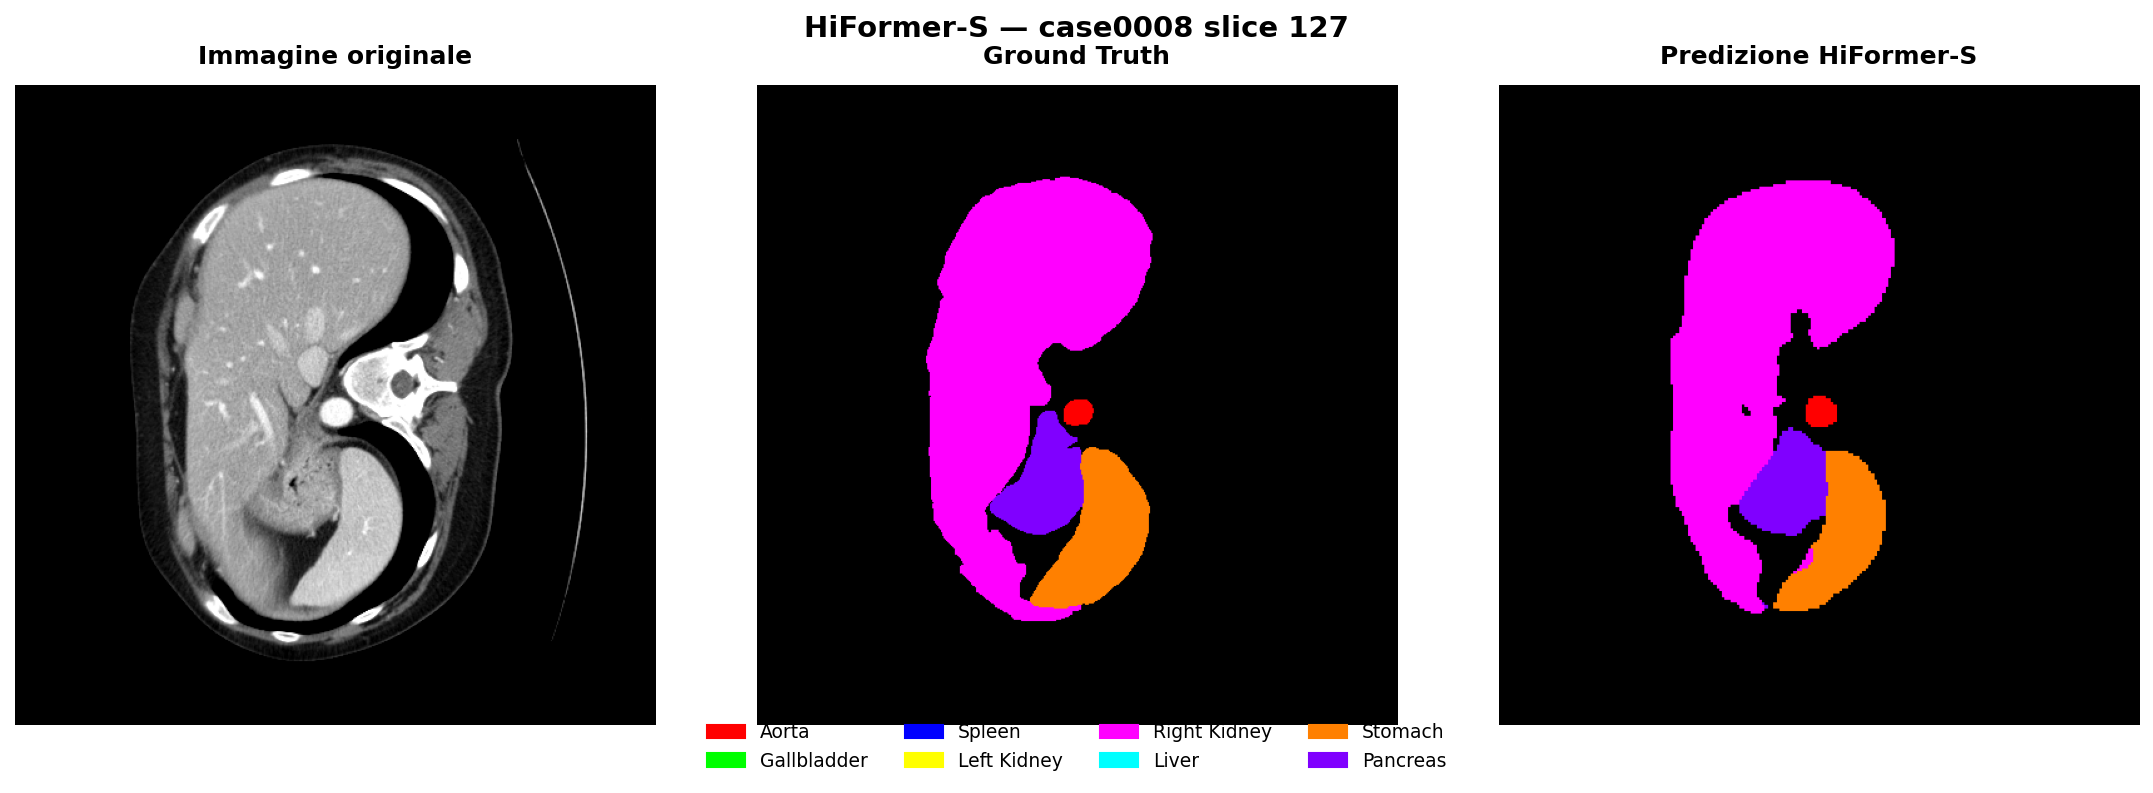

Salvato: /content/drive/MyDrive/HiFormer/results/prediction_example.png


In [57]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
import h5py
from scipy.ndimage import zoom

import sys
sys.path.insert(0, '/content/hiformer_project')
PROJECT_MODS = ('models', 'configs', 'datasets', 'trainer', 'utils', 'evaluate')
for mod in list(sys.modules.keys()):
    if any(mod == m or mod.startswith(m + '.') for m in PROJECT_MODS):
        del sys.modules[mod]

from configs.HiFormer_configs import get_hiformer_s_config
from models.HiFormer import HiFormer, load_pretrained_swin

config = get_hiformer_s_config()
model  = HiFormer(config).cuda()
model.load_state_dict(torch.load(f'{snapshot_path}/best_model.pth', map_location='cuda'))
model.eval()

ORGAN_NAMES = ['Background','Aorta','Gallbladder','Spleen','Left Kidney',
               'Right Kidney','Liver','Stomach','Pancreas']
COLORS = [
    [0,0,0],[255,0,0],[0,255,0],[0,0,255],[255,255,0],
    [255,0,255],[0,255,255],[255,128,0],[128,0,255]
]

def label_to_rgb(label):
    rgb = np.zeros((*label.shape, 3), dtype=np.uint8)
    for cls_idx, color in enumerate(COLORS):
        rgb[label == cls_idx] = color
    return rgb

case = 'case0008'
path = f'/content/drive/MyDrive/HiFormer/data/Synapse/test_vol_h5/{case}.npy.h5'
with h5py.File(path, 'r') as f:
    image = f['image'][:]
    label = f['label'][:]

organ_counts = [(label[i] > 0).sum() for i in range(image.shape[0])]
best_slice   = int(np.argmax(organ_counts))
print(f"Slice con più organi: {best_slice} / {image.shape[0]}")

slc = image[best_slice]
gt  = label[best_slice]
x, y = slc.shape

slc_resized = zoom(slc, (224/x, 224/y), order=3)
inp = torch.from_numpy(slc_resized).unsqueeze(0).unsqueeze(0).float().cuda()

with torch.no_grad():
    out  = model(inp)
    pred = torch.argmax(torch.softmax(out, dim=1), dim=1).squeeze(0).cpu().numpy()

pred_orig = zoom(pred, (x/224, y/224), order=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(slc,            cmap='gray'); axes[0].set_title('Immagine originale'); axes[0].axis('off')
axes[1].imshow(label_to_rgb(gt));            axes[1].set_title('Ground Truth');        axes[1].axis('off')
axes[2].imshow(label_to_rgb(pred_orig));     axes[2].set_title('Predizione HiFormer-S'); axes[2].axis('off')

patches = [mpatches.Patch(color=np.array(COLORS[i])/255, label=ORGAN_NAMES[i])
           for i in range(1, len(ORGAN_NAMES))]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5,-0.05))
plt.suptitle(f'HiFormer-S — {case} slice {best_slice}', fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = '/content/drive/MyDrive/HiFormer/results/prediction_example.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato: {save_path}")

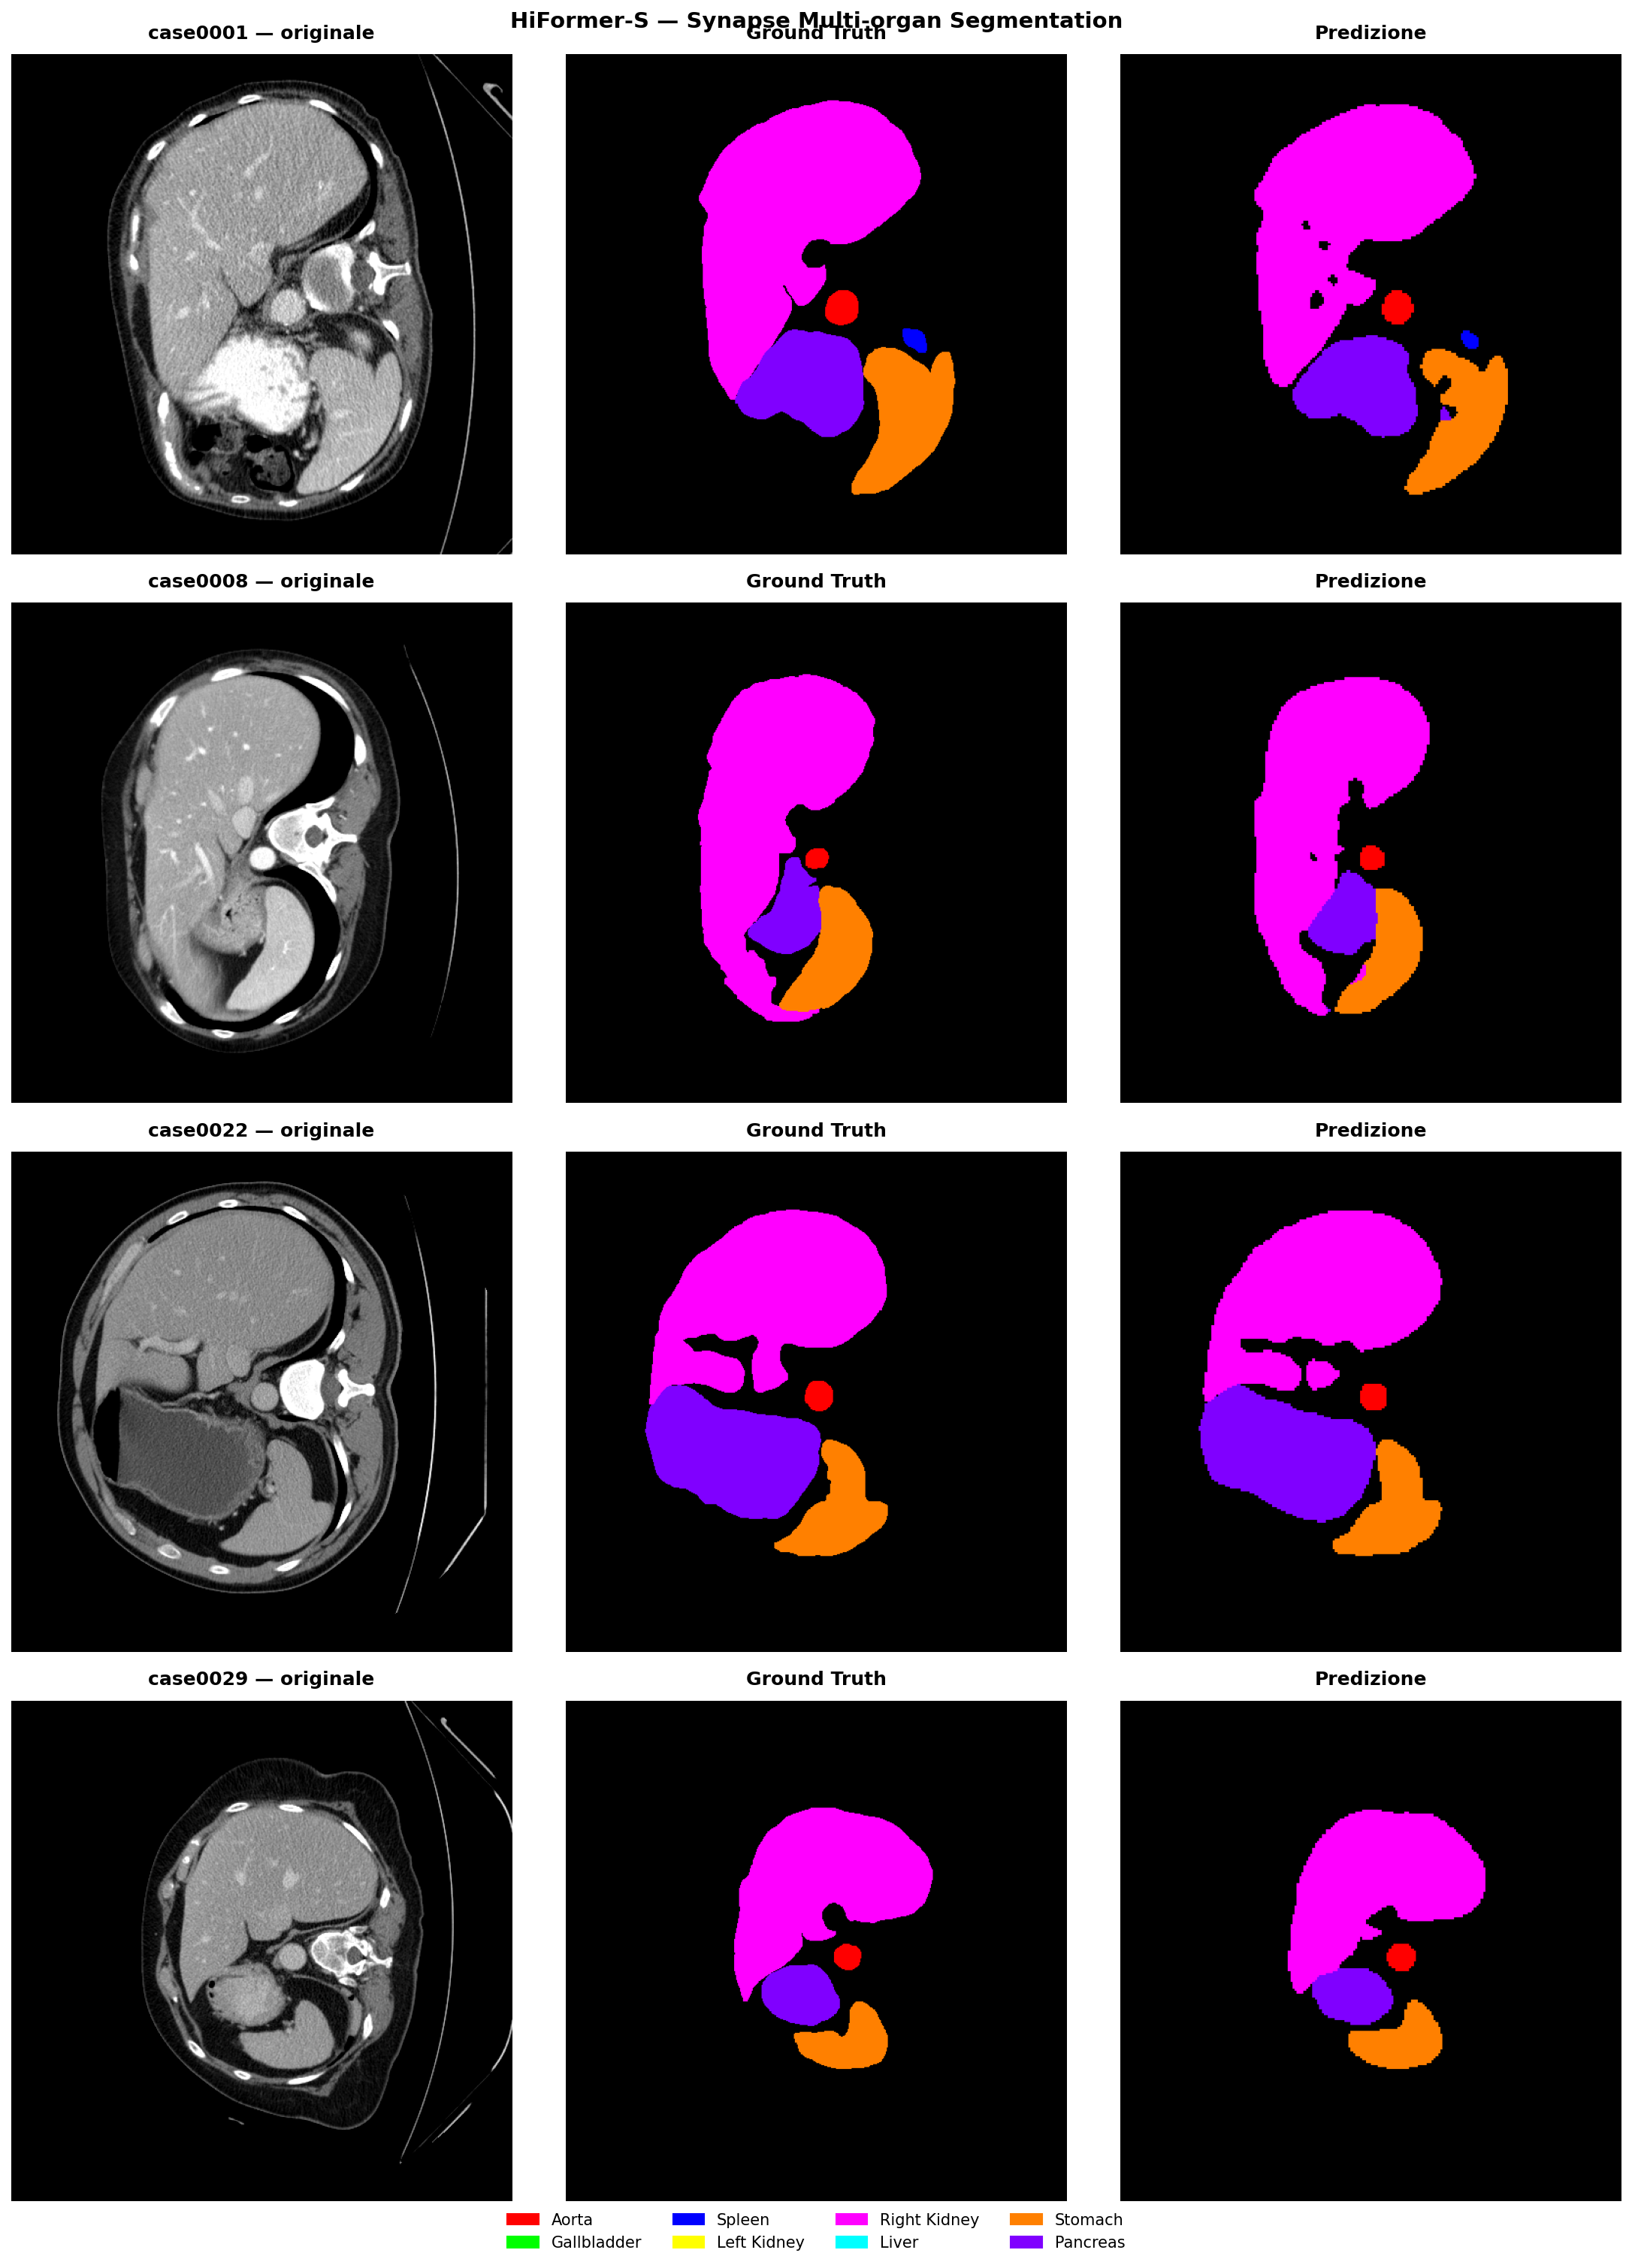

Salvato: /content/drive/MyDrive/HiFormer/results/prediction_multicaso.png


In [58]:
fig, axes = plt.subplots(4, 3, figsize=(15, 20))
test_cases_vis = ['case0001', 'case0008', 'case0022', 'case0029']

for row, case in enumerate(test_cases_vis):
    path = f'/content/drive/MyDrive/HiFormer/data/Synapse/test_vol_h5/{case}.npy.h5'
    with h5py.File(path, 'r') as f:
        image = f['image'][:]
        label = f['label'][:]

    organ_counts = [(label[i] > 0).sum() for i in range(image.shape[0])]
    best_slice   = int(np.argmax(organ_counts))

    slc = image[best_slice]; gt = label[best_slice]; x, y = slc.shape
    slc_resized = zoom(slc, (224/x, 224/y), order=3)
    inp = torch.from_numpy(slc_resized).unsqueeze(0).unsqueeze(0).float().cuda()

    with torch.no_grad():
        out  = model(inp)
        pred = torch.argmax(torch.softmax(out, dim=1), dim=1).squeeze(0).cpu().numpy()
    pred_orig = zoom(pred, (x/224, y/224), order=0)

    axes[row, 0].imshow(slc, cmap='gray');         axes[row, 0].set_title(f'{case} — originale'); axes[row, 0].axis('off')
    axes[row, 1].imshow(label_to_rgb(gt));          axes[row, 1].set_title('Ground Truth');         axes[row, 1].axis('off')
    axes[row, 2].imshow(label_to_rgb(pred_orig));   axes[row, 2].set_title('Predizione');           axes[row, 2].axis('off')

patches = [mpatches.Patch(color=np.array(COLORS[i])/255, label=ORGAN_NAMES[i])
           for i in range(1, len(ORGAN_NAMES))]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5,-0.02))
plt.suptitle('HiFormer-S — Synapse Multi-organ Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = '/content/drive/MyDrive/HiFormer/results/prediction_multicaso.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato: {save_path}")

## 15. Grafici dei risultati

Carico: /content/drive/MyDrive/HiFormer/results/results_20260316_1654_best_model.csv
Epoche: 100 | Mean Dice: 0.7039 | Mean HD95: 26.10 mm


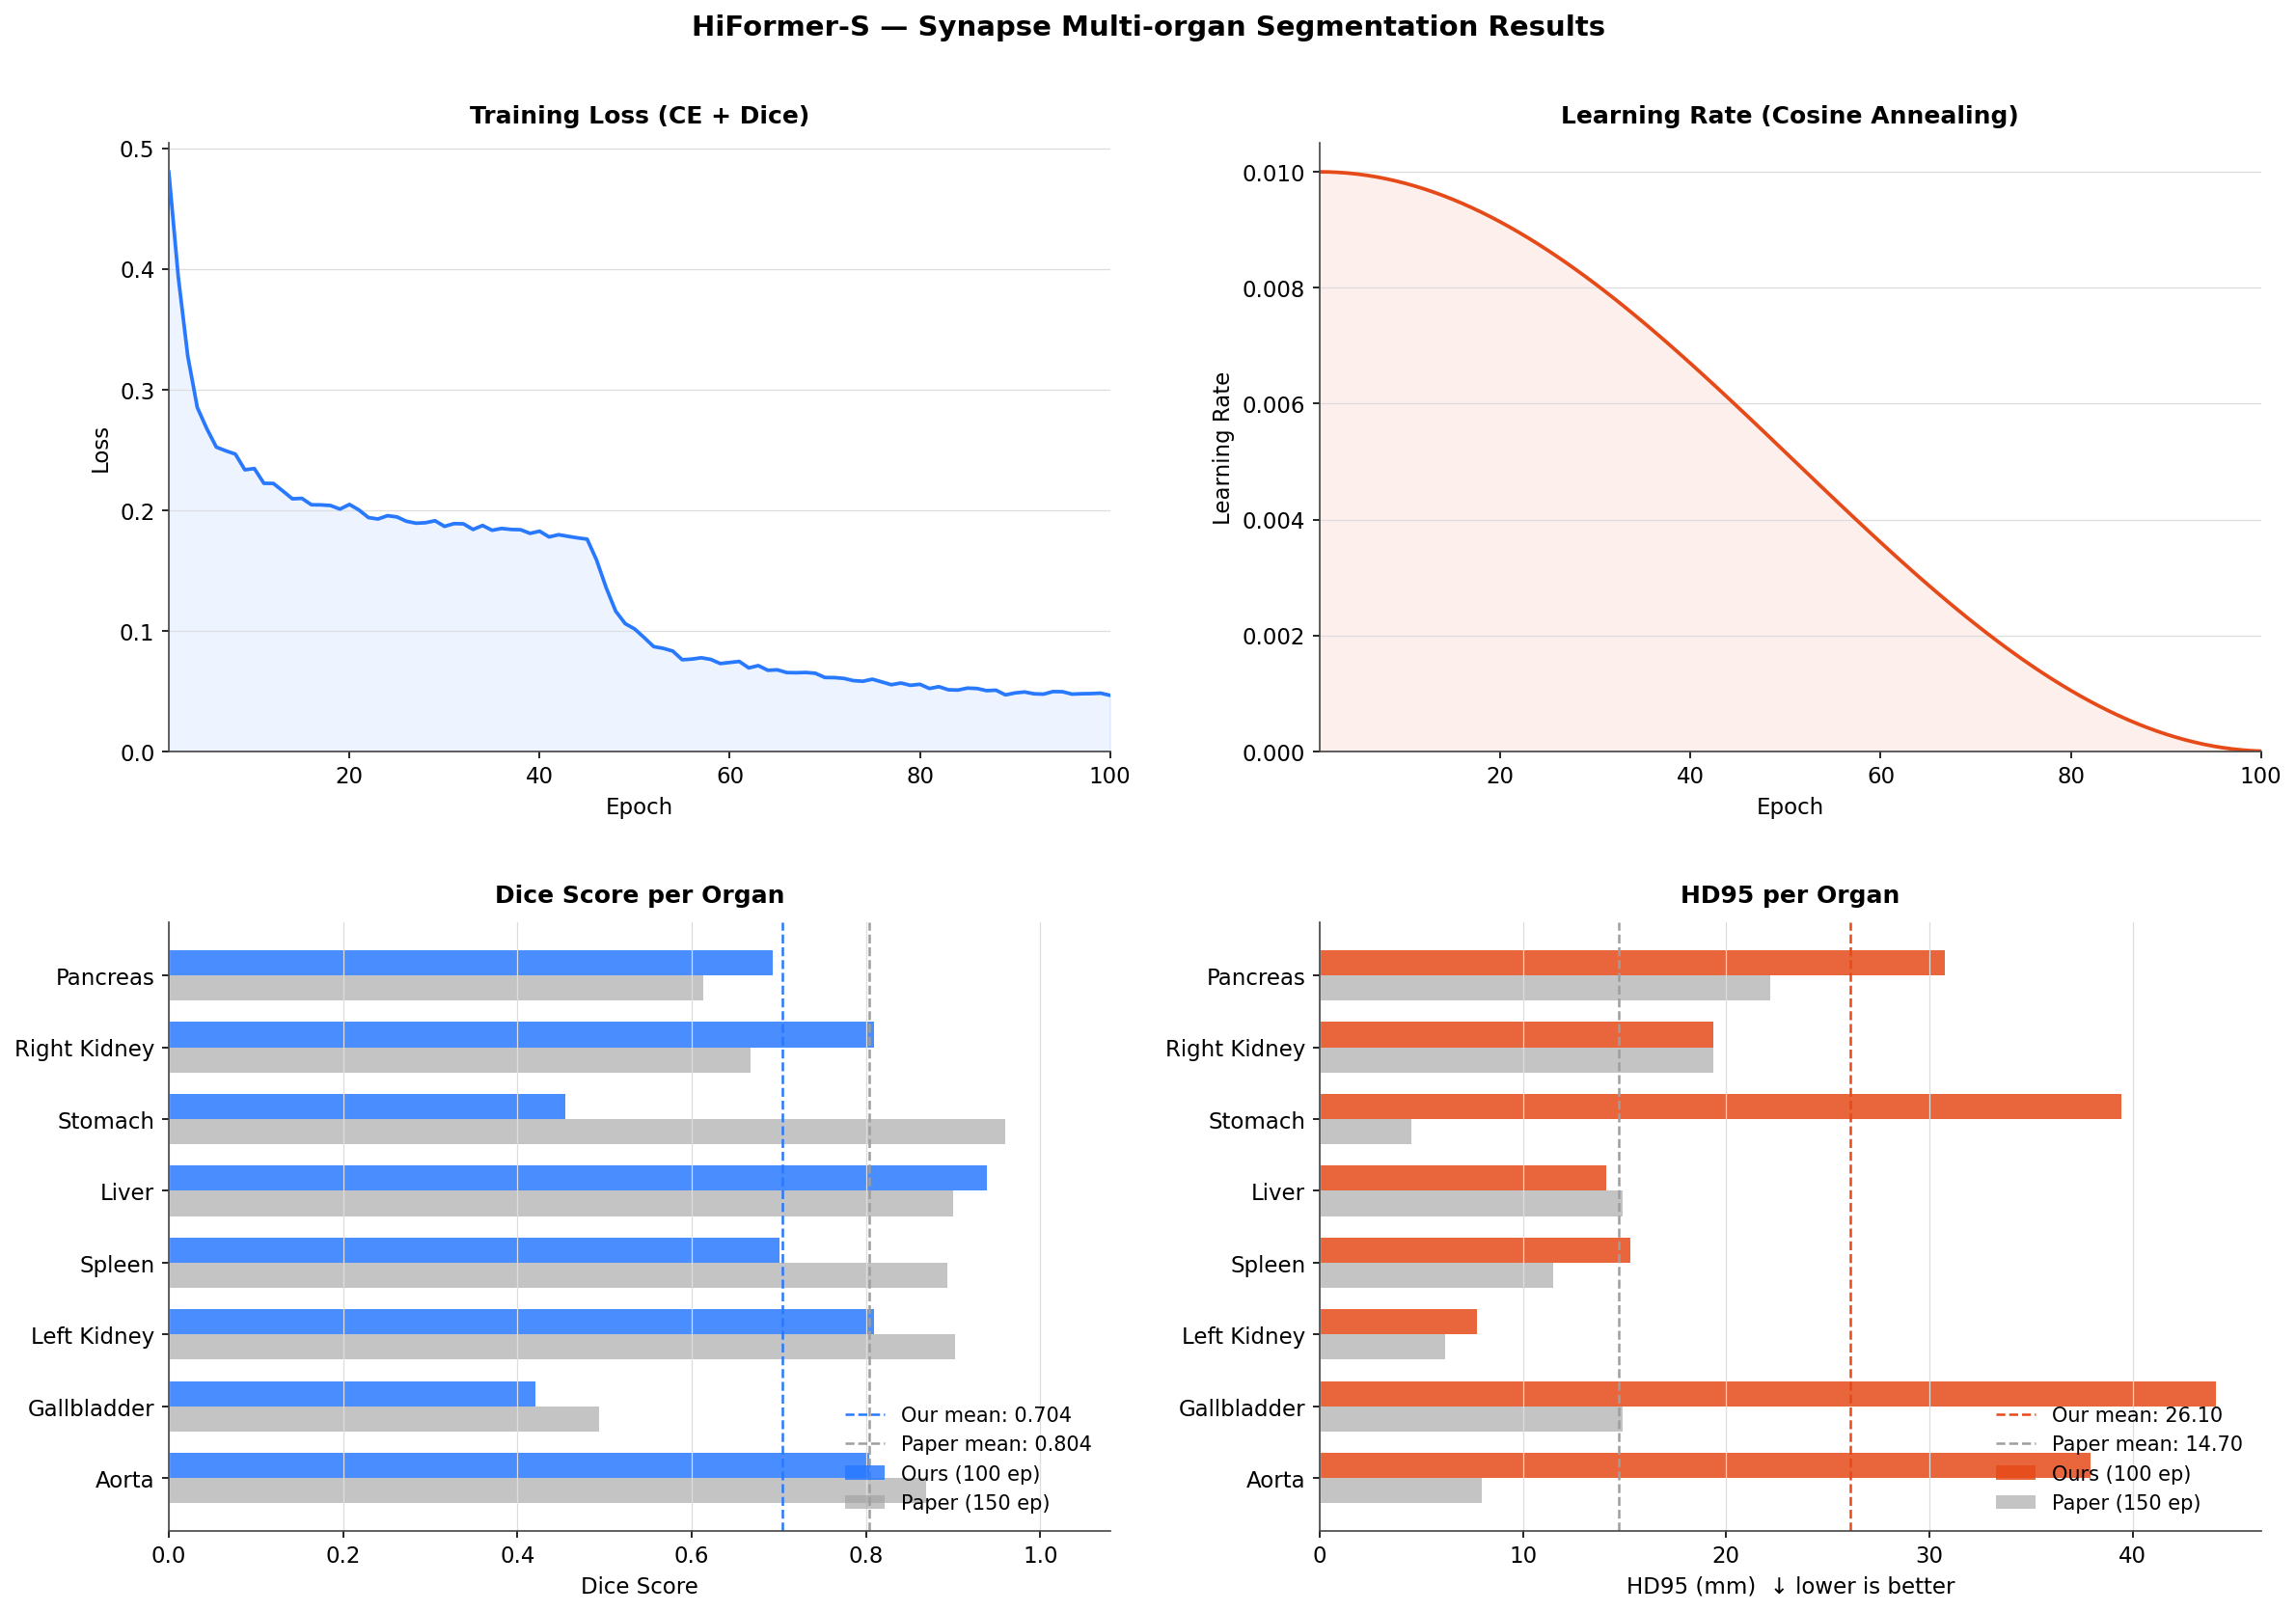

Salvato: /content/drive/MyDrive/HiFormer/results/training_summary.png


In [59]:
import csv
import math
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Leggo i risultati dal CSV più recente nella cartella results
import glob, os
results_dir = '/content/drive/MyDrive/HiFormer/results'
csv_files   = sorted(glob.glob(f'{results_dir}/results_*.csv'))
csv_path    = csv_files[-1]   # il più recente
print(f"Carico: {csv_path}")

organ_names, dice_scores, hd95_scores = [], [], []
with open(csv_path, 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row['Organ'] == 'Mean':
            mean_dice = float(row['Dice'])
            mean_hd95 = float(row['HD95_mm'])
        else:
            organ_names.append(row['Organ'])
            dice_scores.append(float(row['Dice']))
            hd95_scores.append(float(row['HD95_mm']))

# Leggo loss da TensorBoard (run più lunga)
log_dir = os.path.join(snapshot_path, 'log')
ea      = EventAccumulator(log_dir); ea.Reload()
all_loss = [(s.step, s.value) for s in ea.Scalars('train/epoch_loss')]

runs, current, prev_step = [], [], -1
for step, val in all_loss:
    if step <= prev_step: runs.append(current); current = []
    current.append((step, val)); prev_step = step
runs.append(current)
longest = max(runs, key=len)
loss    = [v for _, v in longest]
epochs  = list(range(1, len(loss)+1))
N       = len(epochs)

base_lr, eta_min = 0.01, 1e-6
lr = [eta_min + 0.5*(base_lr-eta_min)*(1+math.cos(math.pi*e/N)) for e in range(N)]

# Valori paper HiFormer-S (150 ep)
paper_dice = [0.869, 0.494, 0.902, 0.893, 0.900, 0.960, 0.668, 0.613]
paper_hd95 = [7.96, 14.90, 6.15, 11.48, 14.90, 4.51, 19.38, 22.18]

print(f"Epoche: {N} | Mean Dice: {mean_dice:.4f} | Mean HD95: {mean_hd95:.2f} mm")

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,
    'axes.linewidth':0.8,'axes.edgecolor':'#444444',
    'axes.titlesize':12,'axes.titleweight':'bold','axes.titlepad':10,
    'grid.color':'#dddddd','grid.linewidth':0.6,
    'legend.frameon':False,'legend.fontsize':10,'figure.dpi':150
})

BLUE='#2979FF'; CORAL='#E64A19'; GRAY='#9E9E9E'
fig = plt.figure(figsize=(16, 11)); fig.patch.set_facecolor('white')

ax1 = fig.add_subplot(2,2,1)
ax1.plot(epochs, loss, color=BLUE, linewidth=1.8, zorder=3)
ax1.fill_between(epochs, loss, alpha=0.08, color=BLUE)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss (CE + Dice)'); ax1.grid(True, axis='y')
ax1.set_xlim(1, N); ax1.set_ylim(bottom=0)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2 = fig.add_subplot(2,2,2)
ax2.plot(epochs, lr, color=CORAL, linewidth=1.8)
ax2.fill_between(epochs, lr, alpha=0.08, color=CORAL)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate (Cosine Annealing)'); ax2.grid(True, axis='y')
ax2.set_xlim(1, N); ax2.set_ylim(bottom=0)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

ax3 = fig.add_subplot(2,2,3)
y = range(len(organ_names)); h = 0.35
ax3.barh([i+h/2 for i in y], dice_scores, height=h, color=BLUE, alpha=0.85, label=f'Ours ({N} ep)')
ax3.barh([i-h/2 for i in y], paper_dice,  height=h, color=GRAY, alpha=0.6,  label='Paper (150 ep)')
ax3.axvline(mean_dice, color=BLUE, linestyle='--', linewidth=1.2, label=f'Our mean: {mean_dice:.3f}')
ax3.axvline(0.8039,    color=GRAY, linestyle='--', linewidth=1.2, label='Paper mean: 0.804')
ax3.set_yticks(list(y)); ax3.set_yticklabels(organ_names)
ax3.set_xlabel('Dice Score'); ax3.set_title('Dice Score per Organ')
ax3.set_xlim(0, 1.08); ax3.legend(loc='lower right'); ax3.grid(True, axis='x')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

ax4 = fig.add_subplot(2,2,4)
ax4.barh([i+h/2 for i in y], hd95_scores, height=h, color=CORAL, alpha=0.85, label=f'Ours ({N} ep)')
ax4.barh([i-h/2 for i in y], paper_hd95,  height=h, color=GRAY,  alpha=0.6,  label='Paper (150 ep)')
ax4.axvline(mean_hd95, color=CORAL, linestyle='--', linewidth=1.2, label=f'Our mean: {mean_hd95:.2f}')
ax4.axvline(14.70,     color=GRAY,  linestyle='--', linewidth=1.2, label='Paper mean: 14.70')
ax4.set_yticks(list(y)); ax4.set_yticklabels(organ_names)
ax4.set_xlabel('HD95 (mm)  ↓ lower is better'); ax4.set_title('HD95 per Organ')
ax4.legend(loc='lower right'); ax4.grid(True, axis='x')
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

fig.suptitle('HiFormer-S — Synapse Multi-organ Segmentation Results',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(h_pad=3.0, w_pad=2.5)

save_path = '/content/drive/MyDrive/HiFormer/results/training_summary.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Salvato: {save_path}")

In [62]:
import h5py
import numpy as np

with h5py.File('/content/drive/MyDrive/HiFormer/data/Synapse/test_vol_h5/case0008.npy.h5', 'r') as f:
    label = f['label'][:]

print(f"Shape volume: {label.shape}")
print(f"Classi presenti e conteggio voxel:")
classi, conteggi = np.unique(label, return_counts=True)
for c, n in zip(classi, conteggi):
    print(f"  classe {int(c):2d} → {n:8d} voxel")

Shape volume: (148, 512, 512)
Classi presenti e conteggio voxel:
  classe  0 → 37662412 voxel
  classe  1 →    27230 voxel
  classe  2 →    10341 voxel
  classe  3 →     6910 voxel
  classe  4 →     6547 voxel
  classe  5 →   811452 voxel
  classe  6 →    53554 voxel
  classe  7 →   128073 voxel
  classe  8 →    90793 voxel


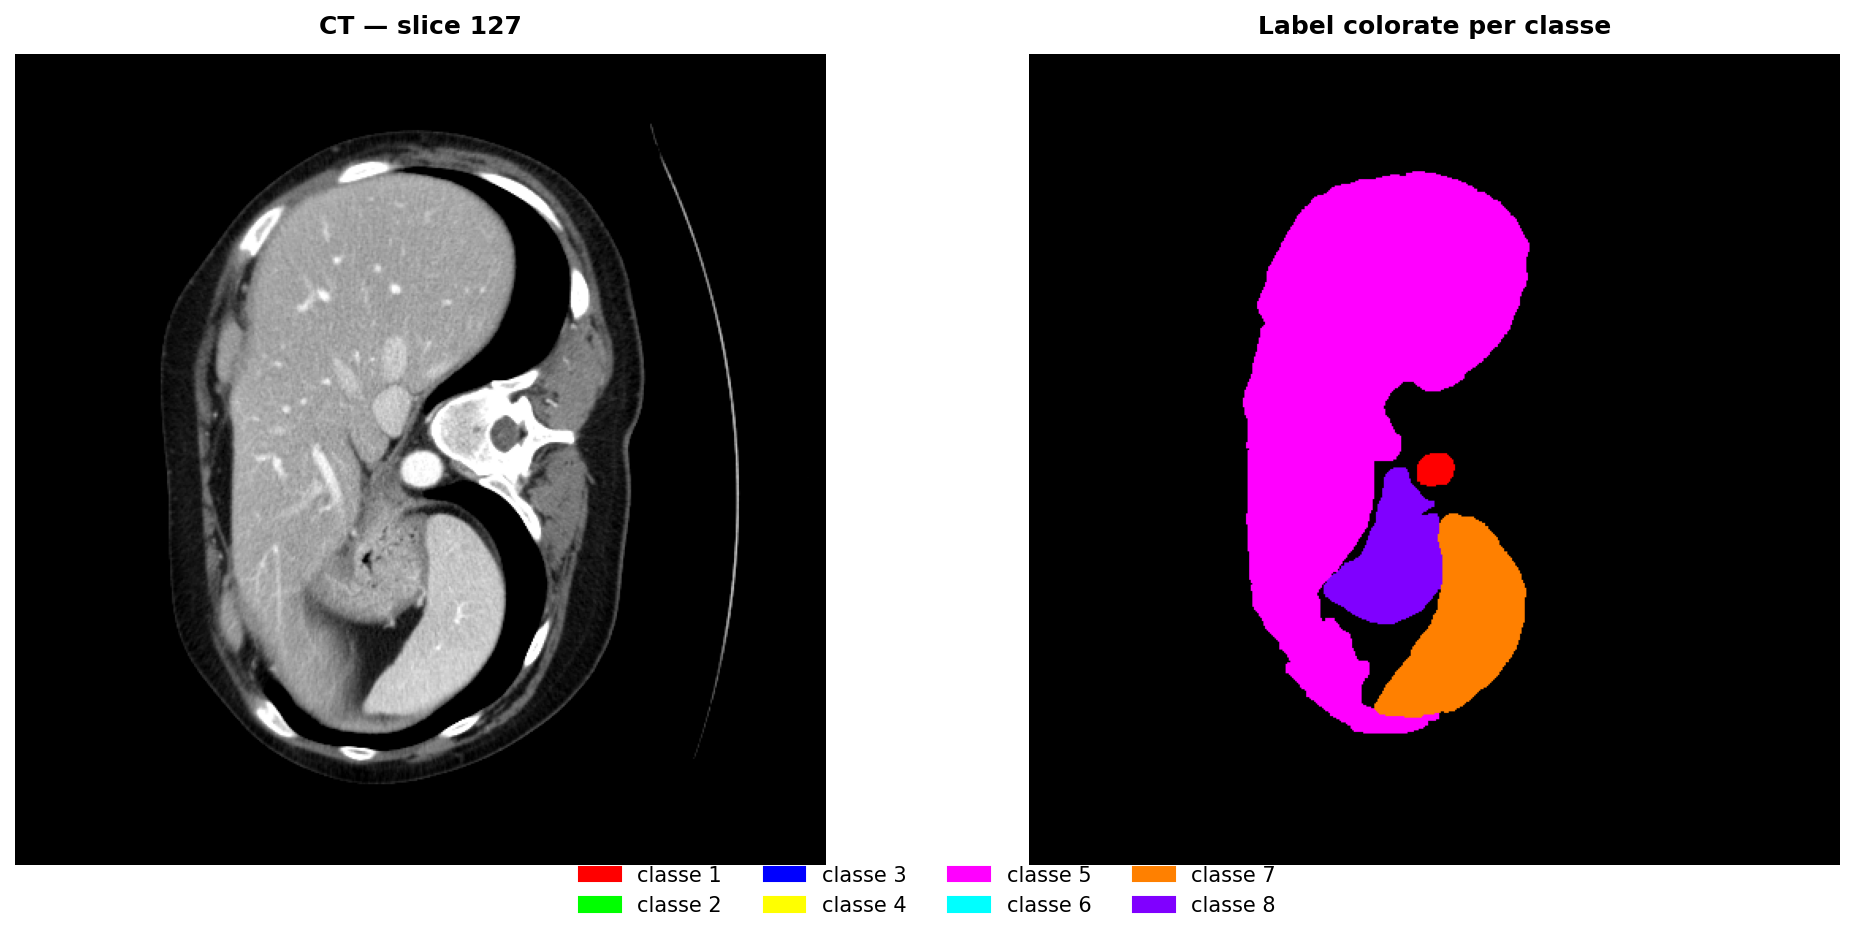

Slice visualizzata: 127


In [63]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

with h5py.File('/content/drive/MyDrive/HiFormer/data/Synapse/test_vol_h5/case0008.npy.h5', 'r') as f:
    image = f['image'][:]
    label = f['label'][:]

# Slice centrale con più organi
organ_counts = [(label[i] > 0).sum() for i in range(label.shape[0])]
best_slice   = int(np.argmax(organ_counts))

COLORS = [
    [0,0,0],[255,0,0],[0,255,0],[0,0,255],[255,255,0],
    [255,0,255],[0,255,255],[255,128,0],[128,0,255]
]

slc = label[best_slice]
rgb = np.zeros((*slc.shape, 3), dtype=np.uint8)
for i, c in enumerate(COLORS):
    rgb[slc == i] = c

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(image[best_slice], cmap='gray')
axes[0].set_title(f'CT — slice {best_slice}')
axes[0].axis('off')

axes[1].imshow(rgb)
axes[1].set_title('Label colorate per classe')
axes[1].axis('off')

# legenda con numero classe
patches = [mpatches.Patch(color=np.array(COLORS[i])/255, label=f'classe {i}')
           for i in range(1, 9)]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()
print(f"Slice visualizzata: {best_slice}")

In [64]:
# Guarda slice più in alto dove appaiono milza e reni separati
for sl in [60, 80, 100, 110, 120]:
    classi_in_slice = np.unique(label[sl])
    print(f"slice {sl}: classi presenti = {classi_in_slice}")

slice 60: classi presenti = [0]
slice 80: classi presenti = [0 1]
slice 100: classi presenti = [0 1 3 4 5 6]
slice 110: classi presenti = [0 1 2 3 4 5 6 7 8]
slice 120: classi presenti = [0 1 5 7 8]


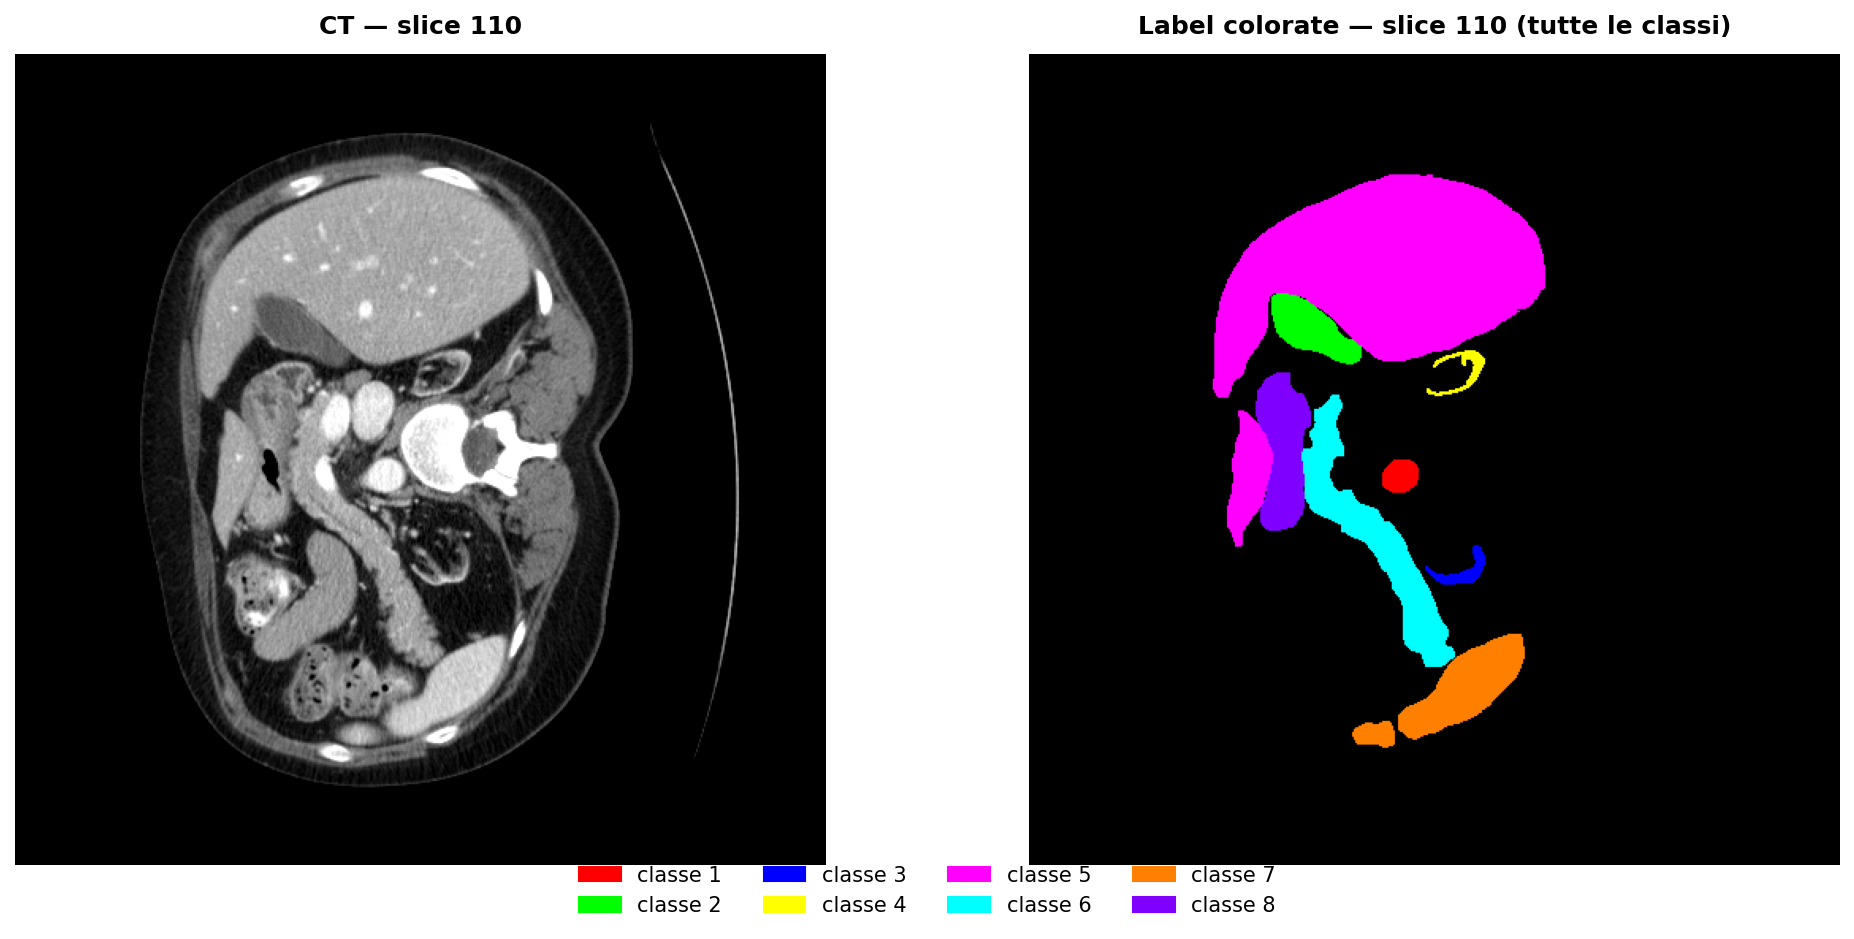

In [65]:
# Visualizza slice 110 dove ci sono tutti e 8 gli organi
sl = 110
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(image[sl], cmap='gray')
axes[0].set_title(f'CT — slice {sl}')
axes[0].axis('off')

slc = label[sl]
rgb = np.zeros((*slc.shape, 3), dtype=np.uint8)
for i, c in enumerate(COLORS):
    rgb[slc == i] = c

axes[1].imshow(rgb)
axes[1].set_title('Label colorate — slice 110 (tutte le classi)')
axes[1].axis('off')

patches = [mpatches.Patch(color=np.array(COLORS[i])/255, label=f'classe {i}')
           for i in range(1, 9)]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()